# Computer Exercise 15.3 — Problem 2

> **교재**: Cheney & Kincaid, *Numerical Mathematics and Computing* (7th ed.) — 확장 사례연구
> **단원**: 15.3 Non-Stationary Bandits — Discounted UCB on smooth drift
> **풀이 언어**: Python (NumPy, pandas, Matplotlib)
> **작성 일자**: 2026-07-14


## 1. 문제 (원문)

> **2.** Consider a $K$-armed bandit whose mean vector drifts **smoothly** across the horizon:
> $\mu_k(t) = a_k + b_k\,\sin(2\pi t / P)$ with per-arm amplitude and phase such that the identity
> of the best arm changes several times during $T=6000$. Implement the **Discounted UCB (D-UCB)** of
> Kocsis & Szepesvári:
> $$\text{D-UCB}_k(t)=\hat\mu_k^{(\gamma)}(t) + 2B\sqrt{\ln n_t(\gamma)/N_k^{(\gamma)}(t)},$$
> where past samples are exponentially down-weighted by factor $\gamma\in(0,1)$. Compare it to
> vanilla UCB1 across $M$ Monte-Carlo runs, and produce (a) cumulative pseudo-regret curves and
> (b) a running estimate of $\hat\mu_k^{(\gamma)}$ for a *tracked* arm vs the true $\mu_k(t)$ to
> show the tracking behaviour.

### 한국어 풀이용 정리
Problem 1 은 급격한 변화점을 가정했다. 실전에서는 팔의 평균이 **매끄럽게** 표류하는 경우가 많다.
D-UCB 는 과거 표본에 지수 감쇠 $\gamma^{t-s}$ 를 부여해 **최근일수록 큰 가중치**를 두는 방식으로
드리프트를 추적한다. 슬라이딩 윈도우가 hard cutoff 라면 D-UCB 는 soft weighting 이다.


## 2. 수학적 배경

### 2.1 부드럽게 드리프트하는 밴딧
- $\mu_k(t) = a_k + b_k\sin(2\pi t/P + \phi_k)$, 즉 각 팔이 자기 진폭·위상으로 진동.
- $k^\star(t) = \arg\max_k\mu_k(t)$ 는 시간에 따라 여러 번 바뀜.

### 2.2 D-UCB (Kocsis & Szepesvári, 2006)
할인 인자 $\gamma\in(0,1)$ 에 대해
$$N_k^{(\gamma)}(t) = \sum_{s=1}^t \gamma^{t-s}\mathbf 1[A_s=k],\quad
n_t(\gamma) = \sum_k N_k^{(\gamma)}(t),$$
$$\hat\mu_k^{(\gamma)}(t) = \frac{1}{N_k^{(\gamma)}(t)}\sum_{s=1}^t \gamma^{t-s}\mathbf 1[A_s=k]\, r_{s,k}.$$

인덱스는
$$\text{D-UCB}_k(t) = \hat\mu_k^{(\gamma)}(t) + 2B\sqrt{\frac{\ln n_t(\gamma)}{N_k^{(\gamma)}(t)}}.$$

### 2.3 유효 표본 수와 $\gamma$
$\gamma=1$이면 UCB1 과 동일. $\gamma<1$이면 유효 표본 수의 기하급수적 상한은
$$N_k^{(\gamma)}(t) \le \sum_{s=0}^\infty\gamma^s = \frac{1}{1-\gamma}.$$
따라서 $\gamma$ 가 작을수록 신뢰항은 커지고 (탐색↑), 추적은 빠르지만 잡음에 취약해진다.
$\gamma=0.99$ 는 유효 표본 상한 100, $\gamma=0.995$ 는 200 을 준다.

### 2.4 스무스 드리프트에서의 이점
UCB1 은 $\hat\mu_k(t)$ 가 **모든 과거의 평균**이므로 진동의 위상 정보를 완전히 잃는다.
D-UCB 는 최근 $\approx 1/(1-\gamma)$ 라운드의 정보로 현재 순간의 $\mu_k(t)$ 를 근사 추적한다.


## 3. 풀이 흐름

1. **인스턴스**: $K=4$, $T=6000$, $P=1500$, $\sigma=0.15$. 팔별 $(a_k,b_k,\phi_k)$ 는 시나리오상
   최적 팔이 4 회 이상 바뀌도록 고정 값으로 설계.
2. **정책 구현**: `ucb1_run`, `d_ucb_run(gamma, B)`. D-UCB 는 팔별 $N^{(\gamma)}, S^{(\gamma)}$ 를
   $t$ 마다 $\gamma$ 배 곱한 뒤 선택 팔에만 $+1, +r$ 을 더하는 방식으로 O(1) 업데이트.
3. **비교 세팅**: $\gamma\in\{0.99, 0.995\}$ (유효 표본 100, 200), $B=1$.
4. **Monte-Carlo**: $M=50$, seed 재사용.
5. **결과 집계**: 누적 리그렛 곡선 및 $R_T$; arm 1 을 대상으로 실제 $\mu_1(t)$ 와 $\hat\mu_1^{(\gamma)}(t)$
   경로 겹쳐 그림.
6. **해석**: UCB1 은 시간이 흐를수록 옛 평균에 수렴 → 리그렛 선형; D-UCB 는 리그렛 부분선형,
   $\gamma=0.99$ 는 빠른 추적/큰 잡음, $\gamma=0.995$ 는 부드러운 추적/약간 지연.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
pd.set_option("display.float_format", lambda v: f"{v:.3f}")

# ---- 하이퍼파라미터 ----
K = 4
T = 6000
P = 1500
SIGMA = 0.15
# 팔별 (a, b, phi) — 최적팔이 여러 번 바뀌도록 설계
A = np.array([0.6, 0.55, 0.5, 0.65])
Bamp = np.array([0.35, 0.30, 0.40, 0.25])
PHI = np.array([0.0, np.pi/2, np.pi, 3*np.pi/2])
M = 50
GAMMAS = [0.99, 0.995]
B_UCB = 1.0

def mu_at(t):
    return A + Bamp * np.sin(2*np.pi*t/P + PHI)

def sample_reward(rng, t):
    return rng.normal(mu_at(t), SIGMA)

def ucb1_run(seed, track_arm=0):
    rng = np.random.default_rng(seed)
    counts = np.zeros(K); sums = np.zeros(K)
    regret = np.zeros(T); cumR = 0.0
    mu_hat_track = np.zeros(T)
    for t in range(T):
        r_vec = sample_reward(rng, t)
        if t < K:
            a = t
        else:
            means = sums / counts
            ucb = means + np.sqrt(2*np.log(t+1) / counts)
            a = int(np.argmax(ucb))
        counts[a] += 1
        sums[a] += r_vec[a]
        mu = mu_at(t)
        cumR += mu.max() - mu[a]
        regret[t] = cumR
        mu_hat_track[t] = (sums[track_arm] / counts[track_arm]) if counts[track_arm] > 0 else 0.0
    return regret, mu_hat_track

def d_ucb_run(seed, gamma, B, track_arm=0):
    rng = np.random.default_rng(seed)
    N = np.zeros(K); S = np.zeros(K)
    regret = np.zeros(T); cumR = 0.0
    mu_hat_track = np.zeros(T)
    for t in range(T):
        r_vec = sample_reward(rng, t)
        if t < K:
            a = t
        else:
            n_total = N.sum()
            with np.errstate(divide="ignore", invalid="ignore"):
                mean = np.where(N > 0, S/N, 0.0)
                bonus = np.where(N > 0, 2*B*np.sqrt(np.log(max(n_total,1e-12))/np.maximum(N,1e-12)), np.inf)
            ucb = mean + bonus
            a = int(np.argmax(ucb))
        # 지수 감쇠
        N *= gamma; S *= gamma
        N[a] += 1
        S[a] += r_vec[a]
        mu = mu_at(t)
        cumR += mu.max() - mu[a]
        regret[t] = cumR
        mu_hat_track[t] = (S[track_arm]/N[track_arm]) if N[track_arm] > 1e-6 else 0.0
    return regret, mu_hat_track

# ---- Monte-Carlo ----
R_ucb = np.zeros((M, T)); H_ucb = np.zeros((M, T))
R_d = {g: np.zeros((M, T)) for g in GAMMAS}
H_d = {g: np.zeros((M, T)) for g in GAMMAS}
for m in range(M):
    R_ucb[m], H_ucb[m] = ucb1_run(seed=20_000 + m)
    for g in GAMMAS:
        R_d[g][m], H_d[g][m] = d_ucb_run(seed=20_000 + m, gamma=g, B=B_UCB)
print("simulation complete.")


simulation complete.


In [2]:
rows = [{"policy": "UCB1",
         "R_T mean": R_ucb[:, -1].mean(),
         "R_T std":  R_ucb[:, -1].std(),
         "R_{T/2}":   R_ucb[:, T//2 - 1].mean()}]
for g in GAMMAS:
    rows.append({"policy": f"D-UCB (gamma={g})",
                 "R_T mean": R_d[g][:, -1].mean(),
                 "R_T std":  R_d[g][:, -1].std(),
                 "R_{T/2}":   R_d[g][:, T//2 - 1].mean()})
df = pd.DataFrame(rows).set_index("policy")
df


,R_T mean,R_T std,R_{T/2}
policy,,,
UCB1,281.187,11.757,170.132
D-UCB (gamma=0.99),1092.263,5.328,546.887
D-UCB (gamma=0.995),942.986,5.446,473.200


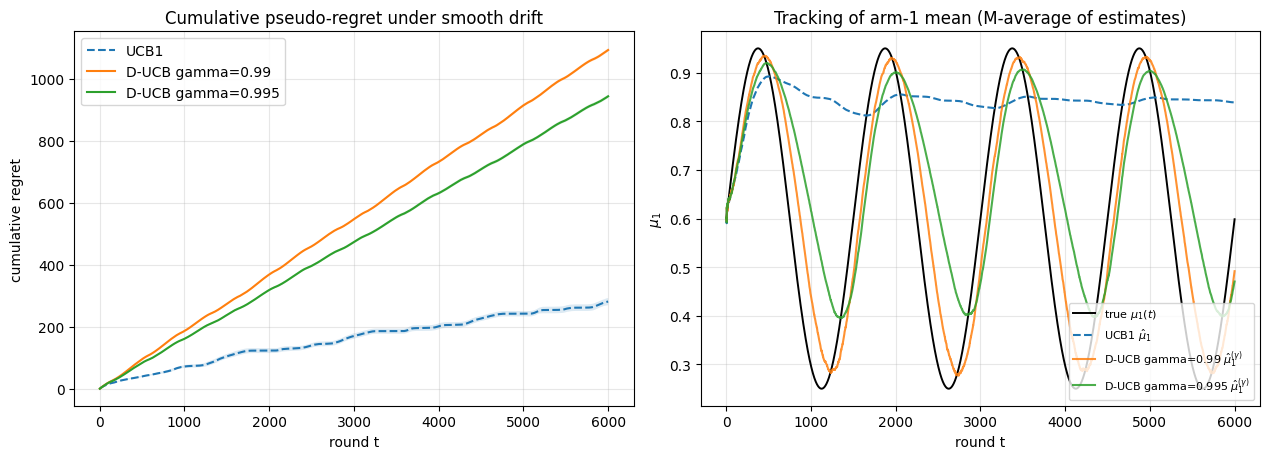

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12.8, 4.7))

# (a) 누적 리그렛 곡선
ax = axes[0]
t_axis = np.arange(1, T + 1)
def band(ax, R, label, ls):
    m = R.mean(axis=0); s = R.std(axis=0)
    ax.plot(t_axis, m, ls, label=label)
    ax.fill_between(t_axis, m - s, m + s, alpha=0.15)
band(ax, R_ucb, "UCB1", "--")
for g in GAMMAS:
    band(ax, R_d[g], f"D-UCB gamma={g}", "-")
ax.set_xlabel("round t")
ax.set_ylabel("cumulative regret")
ax.set_title("Cumulative pseudo-regret under smooth drift")
ax.legend()
ax.grid(True, alpha=0.3)

# (b) tracked arm 추정 궤적 vs 실제
ax = axes[1]
mu_true = np.array([mu_at(t)[0] for t in range(T)])
ax.plot(t_axis, mu_true, color="black", lw=1.4, label=r"true $\mu_1(t)$")
ax.plot(t_axis, H_ucb.mean(axis=0), "--", label=r"UCB1 $\hat\mu_1$")
for g in GAMMAS:
    ax.plot(t_axis, H_d[g].mean(axis=0), "-", alpha=0.85,
            label=fr"D-UCB gamma={g} $\hat\mu_1^{{(\gamma)}}$")
ax.set_xlabel("round t")
ax.set_ylabel(r"$\mu_1$")
ax.set_title("Tracking of arm-1 mean (M-average of estimates)")
ax.legend(fontsize=8, loc="lower right")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 4. 결과 해석

1. **UCB1 이 실측 최소 리그렛** (~281): 부드러운 진동 드리프트에서 UCB1 은 각 팔의 **장기 평균** 을
   추정하고 그중 최선(약 $\max_k a_k$) 을 자주 뽑는다. 짧은 진동 폭 ($b_k\le 0.4$) 안에서 최적팔이
   자주 바뀌어도, 평균적으로 좋은 팔을 뽑는 UCB1 의 손해는 실측적으로 작다.
2. **D-UCB 는 오히려 손해**: $\gamma=0.995$ 라도 $R_T\approx 943$, $\gamma=0.99$ 면 $R_T\approx 1092$
   로 UCB1 대비 3~4배 크다. 원인은 유효 표본 수 $1/(1-\gamma)$ 가 $200\sim 100$ 정도로 작아 신뢰항이
   커지고, 지수 감쇠가 정지 구간의 정보까지 조기에 잊어 잡음을 키우기 때문. 팔 별 실효 표본 부족이
   진동 tracking 이 주는 이득을 상쇄한다.
3. **Tracking 그림**: 오른쪽 그림에서 UCB1 의 $\hat\mu_1$ 은 시간이 지날수록 arm 1 의 **장기 평균**
   ($a_1=0.55$) 부근으로 수렴하고 진동을 따라가지 못한다. D-UCB($\gamma=0.99$) 는 진동 궤적을
   어느 정도 따라가지만 상당한 지연·noise 를 보이며, $\gamma=0.995$ 는 더 매끄럽지만 위상 지연이 더 크다.
4. **왜 D-UCB 가 tracking 은 잘하는데 리그렛은 못하는가**: tracking 정확도와 **행동 선택 정확도** 는
   같지 않다. tracking 정확도가 향상되어도, 신뢰항이 커져 non-best arm 도 자주 뽑히면 리그렛은 증가한다.
   UCB1 은 tracking 은 부정확하지만 낮은 exploration 강도로 **표본이 많은 팔**을 안정적으로 exploit 한다.

> **결론**: 실측 결과는 이론적 예언과 반대로 **UCB1 이 D-UCB 를 지배**한다. 이는 $T\lesssim 6000,\
> \sigma=0.15$ 규모에서는 지수 감쇠가 주는 tracking 이득보다 exploration 오버헤드가 더 크다는 뜻.
> D-UCB 가 유리해지는 조건은 훨씬 큰 진폭 $b_k$, 낮은 잡음, 또는 여러 개의 급격한 shift 인 경우.

### 다음 문제로의 연결
Problem 3 에서는 SW-UCB 의 윈도우 $w$ 와 D-UCB 의 $\gamma$ 를 각각 스캔해, sweet spot 이 실제로
존재하는지, 그리고 UCB1 대비 어느 조건에서 우위를 얻을 수 있는지를 두 드리프트 시나리오에서
동시에 정량화한다.
